In [1]:
import numpy as np
import pandas as pd
import re
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from pathlib import Path
df=Path.cwd().parent.joinpath('projectDM')
crime_df= pd.read_parquet('crime_cleaned.parquet')
pd.set_option('display.max_columns', None)
crime_df.head()

,DR_NO,Date Rptd,DATE OCC,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Status,Status Desc,Crm Cd 1,LAT,LON,hour_occ,min_occ,age_group,type_of_crime,is_night
0,211507896,2021-04-11,2020-11-07,N Hollywood,1502,354,THEFT OF IDENTITY,31,Male,Hispanic,501.0,SINGLE FAMILY DWELLING,IC,Invest Cont,354.0,34.2124,-118.4092,8,45,Young_Adult,2,0
1,201516622,2020-10-21,2020-10-18,N Hollywood,1521,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",32,Male,Hispanic,102.0,SIDEWALK,IC,Invest Cont,230.0,34.1993,-118.4203,18,45,Young_Adult,1,1
2,240913563,2024-12-10,2020-10-30,Van Nuys,933,354,THEFT OF IDENTITY,30,Male,White,501.0,SINGLE FAMILY DWELLING,IC,Invest Cont,354.0,34.1847,-118.4509,12,40,Young_Adult,2,0
3,210704711,2020-12-24,2020-12-24,Wilshire,782,331,THEFT FROM MOTOR VEHICLE,47,Female,Asian,101.0,STREET,IC,Invest Cont,331.0,34.0339,-118.3747,13,10,Middle_Aged_Adult,1,0
4,201418201,2020-10-03,2020-09-29,Pacific,1454,420,THEFT FROM MOTOR VEHICLE,63,Male,Hispanic,103.0,ALLEY,IC,Invest Cont,420.0,33.9813,-118.4350,18,30,Older_Adult,1,1


In [2]:
crime_df = crime_df.drop(columns=["DR_NO","min_occ","Status Desc"])

In [3]:
crime_df

,Date Rptd,DATE OCC,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Status,Crm Cd 1,LAT,LON,hour_occ,age_group,type_of_crime,is_night
0,2021-04-11,2020-11-07,N Hollywood,1502,354,THEFT OF IDENTITY,31,Male,Hispanic,501.0,SINGLE FAMILY DWELLING,IC,354.0,34.2124,-118.4092,8,Young_Adult,2,0
1,2020-10-21,2020-10-18,N Hollywood,1521,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",32,Male,Hispanic,102.0,SIDEWALK,IC,230.0,34.1993,-118.4203,18,Young_Adult,1,1
2,2024-12-10,2020-10-30,Van Nuys,933,354,THEFT OF IDENTITY,30,Male,White,501.0,SINGLE FAMILY DWELLING,IC,354.0,34.1847,-118.4509,12,Young_Adult,2,0
3,2020-12-24,2020-12-24,Wilshire,782,331,THEFT FROM MOTOR VEHICLE,47,Female,Asian,101.0,STREET,IC,331.0,34.0339,-118.3747,13,Middle_Aged_Adult,1,0
4,2020-10-03,2020-09-29,Pacific,1454,420,THEFT FROM MOTOR VEHICLE,63,Male,Hispanic,103.0,ALLEY,IC,420.0,33.9813,-118.4350,18,Older_Adult,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735626,2025-02-02,2025-02-02,Topanga,2103,946,OTHER MISCELLANEOUS CRIME,35,Male,Unknown,101.0,STREET,IC,946.0,34.2259,-118.6126,1,Young_Adult,2,1
735627,2025-02-18,2025-02-18,Hollenbeck,479,237,CHILD NEGLECT (SEE 300 W.I.C.),11,Male,Black,501.0,SINGLE FAMILY DWELLING,IC,237.0,34.0277,-118.1979,10,Child,2,0
735628,2025-01-31,2025-01-30,Newton,1372,850,INDECENT EXPOSURE,16,Female,Hispanic,101.0,STREET,IC,850.0,33.9942,-118.2701,15,Adolescent,2,0
735629,2025-01-17,2025-01-17,Devonshire,1774,624,BATTERY,17,Male,Hispanic,721.0,HIGH SCHOOL,IC,624.0,34.2450,-118.5233,16,Adolescent,2,0


In [4]:
crime_df = crime_df[crime_df["DATE OCC"].dt.year != 2025]

In [5]:
crime_df["DATE OCC"].dt.year.value_counts().sort_index()

DATE OCC
2020    151524
2021    159335
2022    179175
2023    168705
2024     76839
Name: count, dtype: int64

In [6]:
Path.cwd()

WindowsPath('c:/Users/That black girl/Desktop/SPRING 2026 MY COURSE/Data Mining/projectDM')

In [7]:
status_map = {
    "IC": "Investigation Continued",
    "AO": "Adult Other",
    "AA": "Adult Arrest",
    "JA": "Juvenile Arrest",
    "JO": "Juvenile Other",
    "CC": "Case Closed"
}

crime_df["Status_"] = crime_df["Status"].map(status_map)

C:\Users\That black girl\AppData\Local\Temp\ipykernel_43932\3233036993.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crime_df["Status_"] = crime_df["Status"].map(status_map)


In [8]:
crime_df['type_of_crimes'] = crime_df['type_of_crime'].map({
    1: 'Violent',
    2: 'Non Violent'
})

C:\Users\That black girl\AppData\Local\Temp\ipykernel_43932\646425520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crime_df['type_of_crimes'] = crime_df['type_of_crime'].map({


In [9]:


crime_df.loc[:, 'type_numeric'] = crime_df['type_of_crime'].map({
    'Non Violent': 2,
    'Violent': 1
})

C:\Users\That black girl\AppData\Local\Temp\ipykernel_43932\4197795573.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crime_df.loc[:, 'type_numeric'] = crime_df['type_of_crime'].map({


In [10]:
crime_df.drop(columns='type_numeric')

,Date Rptd,DATE OCC,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Status,Crm Cd 1,LAT,LON,hour_occ,age_group,type_of_crime,is_night,Status_,type_of_crimes
0,2021-04-11,2020-11-07,N Hollywood,1502,354,THEFT OF IDENTITY,31,Male,Hispanic,501.0,SINGLE FAMILY DWELLING,IC,354.0,34.2124,-118.4092,8,Young_Adult,2,0,Investigation Continued,Non Violent
1,2020-10-21,2020-10-18,N Hollywood,1521,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",32,Male,Hispanic,102.0,SIDEWALK,IC,230.0,34.1993,-118.4203,18,Young_Adult,1,1,Investigation Continued,Violent
2,2024-12-10,2020-10-30,Van Nuys,933,354,THEFT OF IDENTITY,30,Male,White,501.0,SINGLE FAMILY DWELLING,IC,354.0,34.1847,-118.4509,12,Young_Adult,2,0,Investigation Continued,Non Violent
3,2020-12-24,2020-12-24,Wilshire,782,331,THEFT FROM MOTOR VEHICLE,47,Female,Asian,101.0,STREET,IC,331.0,34.0339,-118.3747,13,Middle_Aged_Adult,1,0,Investigation Continued,Violent
4,2020-10-03,2020-09-29,Pacific,1454,420,THEFT FROM MOTOR VEHICLE,63,Male,Hispanic,103.0,ALLEY,IC,420.0,33.9813,-118.4350,18,Older_Adult,1,1,Investigation Continued,Violent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735573,2024-10-04,2024-09-27,Central,142,440,THEFT PLAIN,42,Female,Black,122.0,"VEHICLE, PASSENGER/TRUCK",IC,440.0,34.0531,-118.2512,23,Middle_Aged_Adult,1,1,Investigation Continued,Violent
735574,2024-08-20,2024-08-17,Olympic,2033,341,THEFT,36,Female,Chinese,207.0,BAR/COCKTAIL/NIGHTCLUB,IC,341.0,34.0617,-118.3066,23,Middle_Aged_Adult,1,1,Investigation Continued,Violent
735575,2024-10-16,2024-10-16,Pacific,1489,341,THEFT,46,Male,Hispanic,223.0,VIDEO RENTAL STORE,IC,341.0,33.9469,-118.3703,15,Middle_Aged_Adult,1,0,Investigation Continued,Violent
735576,2024-10-14,2024-10-11,Hollenbeck,421,341,THEFT,29,Male,Black,210.0,RESTAURANT/FAST FOOD,IC,341.0,34.0675,-118.2240,23,Young_Adult,1,1,Investigation Continued,Violent


In [11]:
crime_df=crime_df.drop(columns='type_numeric')

In [12]:
#crime_df = crime_df.dropna()

In [13]:
#crime_df = crime_df.dropna(subset=["LAT", "LON", "Crm Cd Desc","Premis Desc","Vict Descent"])

In [14]:
crime_df = crime_df.reset_index(drop=True)

In [15]:
crime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735578 entries, 0 to 735577
Data columns (total 21 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Date Rptd       735578 non-null  datetime64[ns]
 1   DATE OCC        735578 non-null  datetime64[ns]
 2   AREA NAME       735578 non-null  category      
 3   Rpt Dist No     735578 non-null  int64         
 4   Crm Cd          735578 non-null  int64         
 5   Crm Cd Desc     735578 non-null  object        
 6   Vict Age        735578 non-null  int64         
 7   Vict Sex        735578 non-null  category      
 8   Vict Descent    735546 non-null  object        
 9   Premis Cd       735577 non-null  float64       
 10  Premis Desc     735349 non-null  category      
 11  Status          735578 non-null  category      
 12  Crm Cd 1        735572 non-null  float64       
 13  LAT             735578 non-null  float64       
 14  LON             735578 non-null  flo

In [16]:
crime_df.select_dtypes(include=["object","category"]).describe()

,AREA NAME,Crm Cd Desc,Vict Sex,Vict Descent,Premis Desc,Status,age_group,Status_,type_of_crimes
count,735578,735578,735578,735546,735349,735578,735578,735578,735578
unique,21,119,3,19,304,6,5,6,2
top,Central,BATTERY,Male,Hispanic,SINGLE FAMILY DWELLING,IC,Young_Adult,Investigation Continued,Violent
freq,52095,73876,370266,291504,160499,564804,315926,564804,384537


In [17]:
crime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735578 entries, 0 to 735577
Data columns (total 21 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Date Rptd       735578 non-null  datetime64[ns]
 1   DATE OCC        735578 non-null  datetime64[ns]
 2   AREA NAME       735578 non-null  category      
 3   Rpt Dist No     735578 non-null  int64         
 4   Crm Cd          735578 non-null  int64         
 5   Crm Cd Desc     735578 non-null  object        
 6   Vict Age        735578 non-null  int64         
 7   Vict Sex        735578 non-null  category      
 8   Vict Descent    735546 non-null  object        
 9   Premis Cd       735577 non-null  float64       
 10  Premis Desc     735349 non-null  category      
 11  Status          735578 non-null  category      
 12  Crm Cd 1        735572 non-null  float64       
 13  LAT             735578 non-null  float64       
 14  LON             735578 non-null  flo

In [18]:
crime_df["DATE OCC"].max()

Timestamp('2024-12-30 00:00:00')

In [19]:
crime_df.reset_index(drop=True)

,Date Rptd,DATE OCC,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Status,Crm Cd 1,LAT,LON,hour_occ,age_group,type_of_crime,is_night,Status_,type_of_crimes
0,2021-04-11,2020-11-07,N Hollywood,1502,354,THEFT OF IDENTITY,31,Male,Hispanic,501.0,SINGLE FAMILY DWELLING,IC,354.0,34.2124,-118.4092,8,Young_Adult,2,0,Investigation Continued,Non Violent
1,2020-10-21,2020-10-18,N Hollywood,1521,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",32,Male,Hispanic,102.0,SIDEWALK,IC,230.0,34.1993,-118.4203,18,Young_Adult,1,1,Investigation Continued,Violent
2,2024-12-10,2020-10-30,Van Nuys,933,354,THEFT OF IDENTITY,30,Male,White,501.0,SINGLE FAMILY DWELLING,IC,354.0,34.1847,-118.4509,12,Young_Adult,2,0,Investigation Continued,Non Violent
3,2020-12-24,2020-12-24,Wilshire,782,331,THEFT FROM MOTOR VEHICLE,47,Female,Asian,101.0,STREET,IC,331.0,34.0339,-118.3747,13,Middle_Aged_Adult,1,0,Investigation Continued,Violent
4,2020-10-03,2020-09-29,Pacific,1454,420,THEFT FROM MOTOR VEHICLE,63,Male,Hispanic,103.0,ALLEY,IC,420.0,33.9813,-118.4350,18,Older_Adult,1,1,Investigation Continued,Violent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735573,2024-10-04,2024-09-27,Central,142,440,THEFT PLAIN,42,Female,Black,122.0,"VEHICLE, PASSENGER/TRUCK",IC,440.0,34.0531,-118.2512,23,Middle_Aged_Adult,1,1,Investigation Continued,Violent
735574,2024-08-20,2024-08-17,Olympic,2033,341,THEFT,36,Female,Chinese,207.0,BAR/COCKTAIL/NIGHTCLUB,IC,341.0,34.0617,-118.3066,23,Middle_Aged_Adult,1,1,Investigation Continued,Violent
735575,2024-10-16,2024-10-16,Pacific,1489,341,THEFT,46,Male,Hispanic,223.0,VIDEO RENTAL STORE,IC,341.0,33.9469,-118.3703,15,Middle_Aged_Adult,1,0,Investigation Continued,Violent
735576,2024-10-14,2024-10-11,Hollenbeck,421,341,THEFT,29,Male,Black,210.0,RESTAURANT/FAST FOOD,IC,341.0,34.0675,-118.2240,23,Young_Adult,1,1,Investigation Continued,Violent


In [20]:
crime_df["Crm Cd"].value_counts()

Crm Cd
624    73876
330    61557
354    61346
230    51495
440    46932
       ...  
882        2
436        1
445        1
926        1
453        1
Name: count, Length: 138, dtype: int64

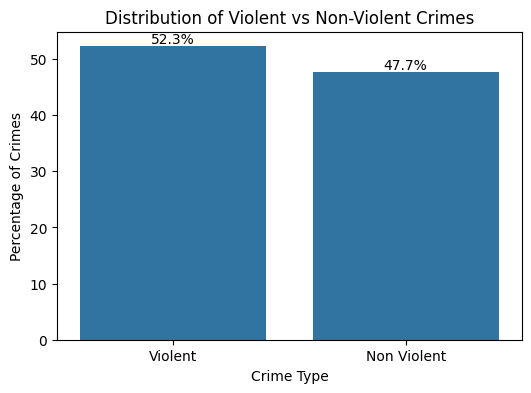

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate percentages
percentages = crime_df['type_of_crimes'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=percentages.index,
    y=percentages.values
)

plt.title('Distribution of Violent vs Non-Violent Crimes')
plt.ylabel('Percentage of Crimes')
plt.xlabel('Crime Type')

# Add percentage labels
for i, v in enumerate(percentages.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.show()

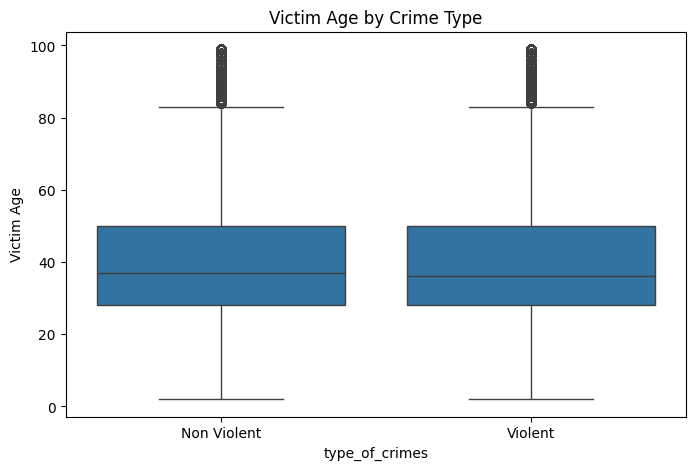

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='type_of_crimes', y='Vict Age', data=crime_df)
plt.title('Victim Age by Crime Type')
plt.ylabel('Victim Age')
plt.show()

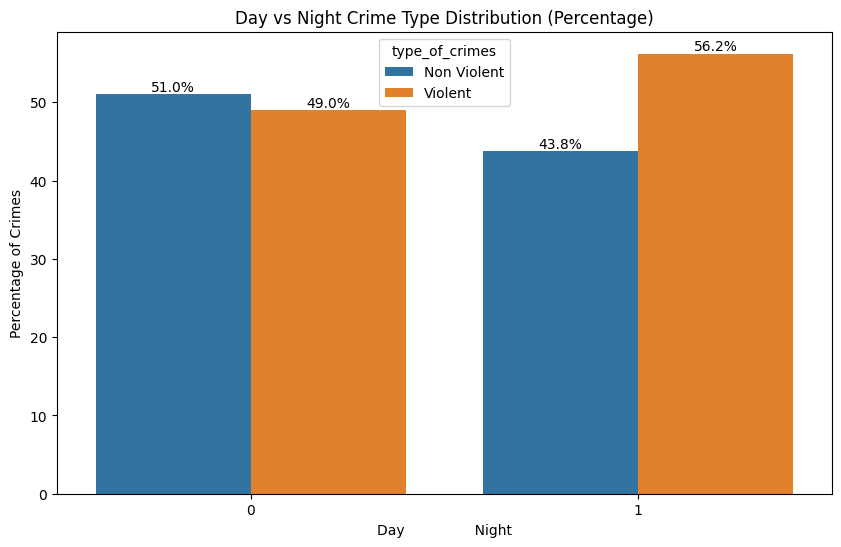

In [23]:

# Calculate counts
day_night = crime_df.groupby(['is_night','type_of_crimes']).size().reset_index(name='count')

# Convert to percentage
day_night['percentage'] = day_night.groupby('is_night')['count'].transform(lambda x: x/x.sum()*100)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=day_night,
    x='is_night',
    y='percentage',
    hue='type_of_crimes'
)

plt.title('Day vs Night Crime Type Distribution (Percentage)')
plt.xlabel('Day                Night')
plt.ylabel('Percentage of Crimes')

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

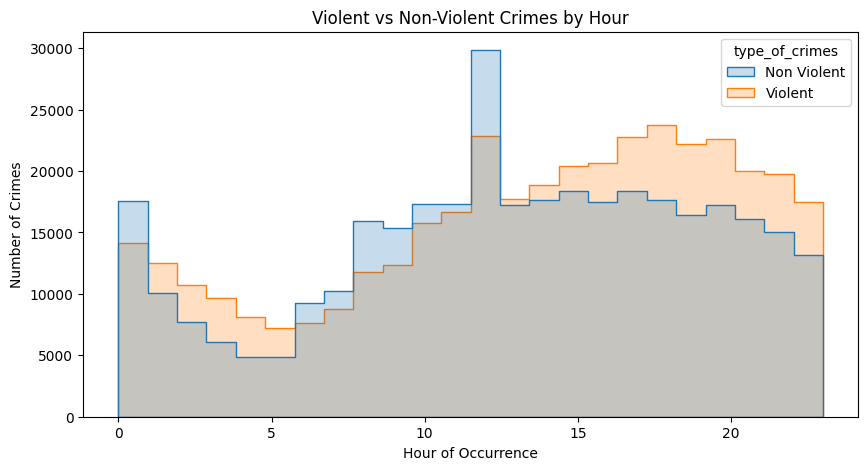

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(data=crime_df, x='hour_occ', hue='type_of_crimes',
             bins=24, kde=False, element="step")
plt.title('Violent vs Non-Violent Crimes by Hour')
plt.xlabel('Hour of Occurrence')
plt.ylabel('Number of Crimes')
plt.show()

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

area_crime = pd.crosstab(
    crime_df['AREA_NAME'],
    crime_df['type_of_crimes']
)

area_crime = area_crime[['Non Violent','Violent']]

area_crime.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=['steelblue','crimson']
)

plt.xticks(rotation=90)
plt.title('Distribution of Crime Types by Area (Stacked)')
plt.xlabel('Area Name')
plt.ylabel('Number of Crimes')

plt.legend(title='Crime Type')

plt.show()

KeyError: 'AREA_NAME'

<Figure size 1200x600 with 0 Axes>

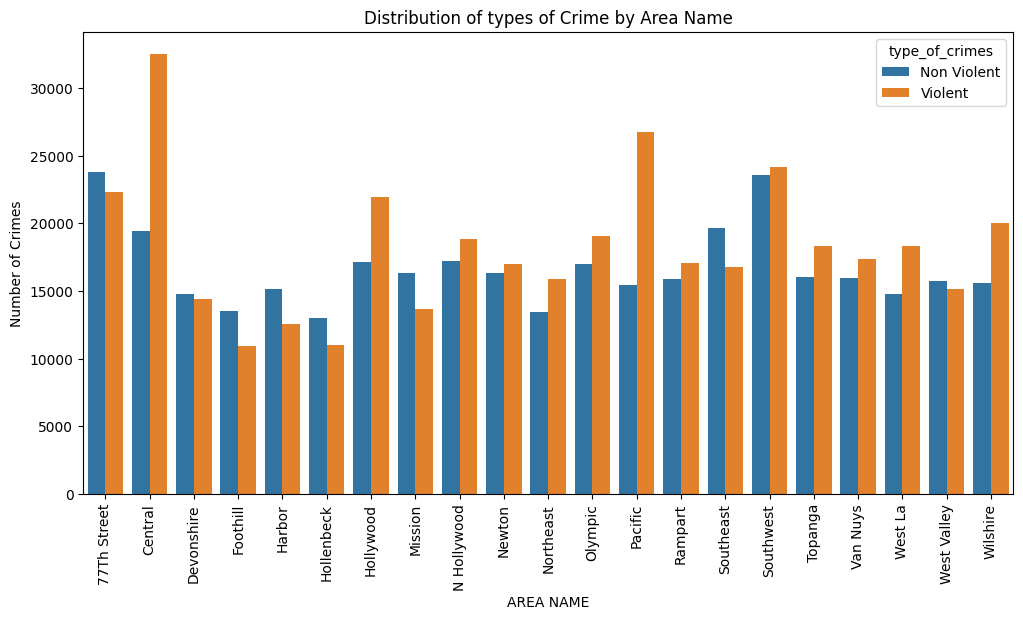

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='AREA NAME',
              hue='type_of_crimes',
              data=crime_df)
plt.xticks(rotation=90)
plt.title('Distribution of types of Crime by Area Name')
plt.ylabel('Number of Crimes')
plt.show()

Is violent crime associated with night vs day?

In [ ]:
from scipy.stats import chi2_contingency

cont_table = pd.crosstab(crime_df['is_night'],
                         crime_df['type_of_crime'])

chi2, p, dof, expected = chi2_contingency(cont_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 3808.8751057253926
p-value: 0.0


In [ ]:
pd.crosstab(crime_df['is_night'],
            crime_df['type_of_crime'])

type_of_crime,1,2
is_night,,
0,196261,204352
1,188276,146689


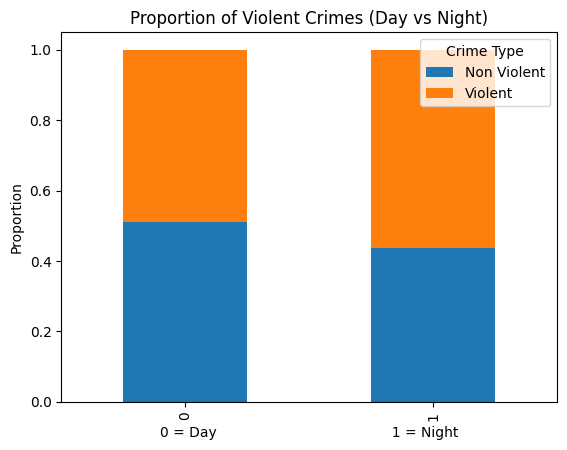

In [ ]:
cont_table = pd.crosstab(crime_df['is_night'],
                         crime_df['type_of_crimes'],
                         normalize='index')

cont_table.plot(kind='bar', stacked=True)

plt.title('Proportion of Violent Crimes (Day vs Night)')
plt.ylabel('Proportion')
plt.xlabel('0 = Day                                        1 = Night')
plt.legend(title='Crime Type')
plt.show()

In [ ]:
cont_table = pd.crosstab(
    crime_df['is_night'],
    crime_df['type_of_crimes'],
    normalize='index'
)

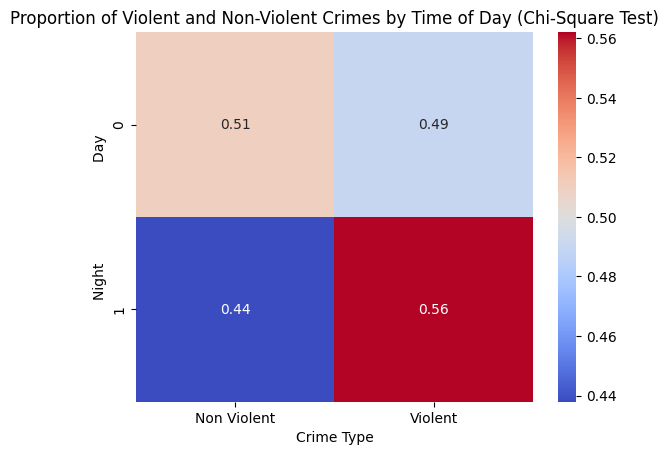

In [ ]:
import seaborn as sns
import matplotlib.pyplot


sns.heatmap(
    cont_table,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Proportion of Violent and Non-Violent Crimes by Time of Day (Chi-Square Test)")
plt.xlabel("Crime Type")
plt.ylabel("Night                       Day")

plt.show()

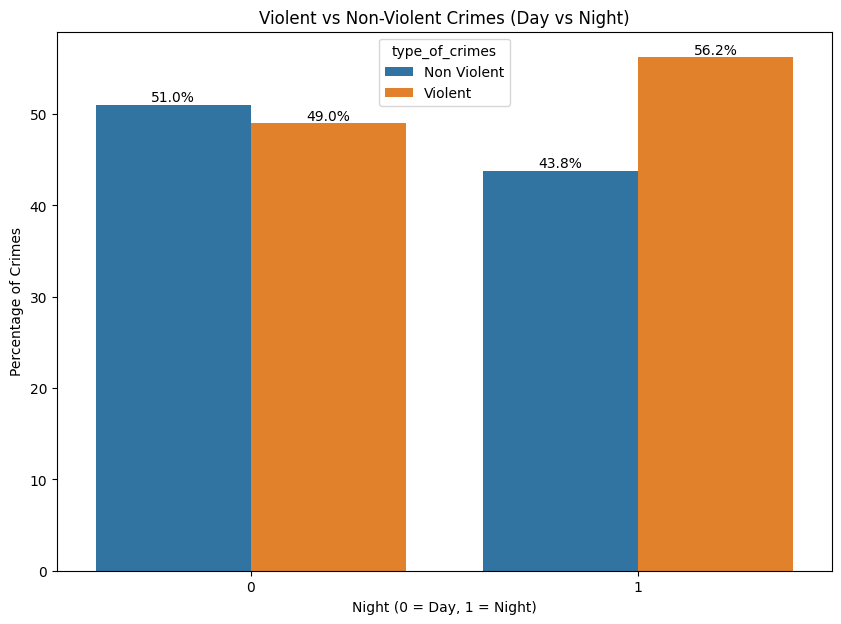

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


data = crime_df.groupby(['is_night', 'type_of_crimes']).size().reset_index(name='count')


data['percentage'] = data.groupby('is_night')['count'].transform(lambda x: x/x.sum()*100)

plt.figure(figsize=(10,7))

ax = sns.barplot(
    data=data,
    x='is_night',
    y='percentage',
    hue='type_of_crimes'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Violent vs Non-Violent Crimes (Day vs Night)')
plt.xlabel('Night (0 = Day, 1 = Night)')
plt.ylabel('Percentage of Crimes')

plt.show()

In [ ]:
# Remove invalid coordinates
crime_df = crime_df[
    (crime_df['LAT'] != 0) &
    (crime_df['LON'] != 0)
]
crime_df

,Date Rptd,DATE OCC,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Status,Crm Cd 1,LAT,LON,hour_occ,age_group,type_of_crime,is_night,Status_,type_of_crimes
0,2021-04-11,2020-11-07,N Hollywood,1502,354,THEFT OF IDENTITY,31,Male,Hispanic,501.0,SINGLE FAMILY DWELLING,IC,354.0,34.2124,-118.4092,8,Young_Adult,2,0,Investigation Continued,Non Violent
1,2020-10-21,2020-10-18,N Hollywood,1521,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",32,Male,Hispanic,102.0,SIDEWALK,IC,230.0,34.1993,-118.4203,18,Young_Adult,1,1,Investigation Continued,Violent
2,2024-12-10,2020-10-30,Van Nuys,933,354,THEFT OF IDENTITY,30,Male,White,501.0,SINGLE FAMILY DWELLING,IC,354.0,34.1847,-118.4509,12,Young_Adult,2,0,Investigation Continued,Non Violent
3,2020-12-24,2020-12-24,Wilshire,782,331,THEFT FROM MOTOR VEHICLE,47,Female,Asian,101.0,STREET,IC,331.0,34.0339,-118.3747,13,Middle_Aged_Adult,1,0,Investigation Continued,Violent
4,2020-10-03,2020-09-29,Pacific,1454,420,THEFT FROM MOTOR VEHICLE,63,Male,Hispanic,103.0,ALLEY,IC,420.0,33.9813,-118.4350,18,Older_Adult,1,1,Investigation Continued,Violent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735573,2024-10-04,2024-09-27,Central,142,440,THEFT PLAIN,42,Female,Black,122.0,"VEHICLE, PASSENGER/TRUCK",IC,440.0,34.0531,-118.2512,23,Middle_Aged_Adult,1,1,Investigation Continued,Violent
735574,2024-08-20,2024-08-17,Olympic,2033,341,THEFT,36,Female,Chinese,207.0,BAR/COCKTAIL/NIGHTCLUB,IC,341.0,34.0617,-118.3066,23,Middle_Aged_Adult,1,1,Investigation Continued,Violent
735575,2024-10-16,2024-10-16,Pacific,1489,341,THEFT,46,Male,Hispanic,223.0,VIDEO RENTAL STORE,IC,341.0,33.9469,-118.3703,15,Middle_Aged_Adult,1,0,Investigation Continued,Violent
735576,2024-10-14,2024-10-11,Hollenbeck,421,341,THEFT,29,Male,Black,210.0,RESTAURANT/FAST FOOD,IC,341.0,34.0675,-118.2240,23,Young_Adult,1,1,Investigation Continued,Violent


In [ ]:
from scipy.stats import f_oneway

violent = crime_df[crime_df['type_of_crime'] == 1]['Vict Age']
non_violent = crime_df[crime_df['type_of_crime'] == 0]['Vict Age']

f_stat, p_value = f_oneway(violent, non_violent)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: nan
p-value: nan


C:\Users\That black girl\AppData\Local\Temp\ipykernel_37844\124957687.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = f_oneway(violent, non_violent)


In [ ]:
crime_df[['LAT', 'LON']].describe()

,LAT,LON
count,733886.000000,733886.000000
mean,34.075752,-118.357245
std,0.110183,0.105317
min,33.705900,-118.667600
25%,34.016200,-118.433800
50%,34.059400,-118.326600
75%,34.166500,-118.276100
max,34.334300,-118.155400


In [ ]:
#plt.figure(figsize=(8,6))
#sns.scatterplot(x='LON', y='LAT',
#                hue='type_of_crimes',
#                data=crime_df,
#                palette={'Non Violent': "blue", 'Violent': "red"},
 #               alpha=0.4)
#plt.title('Crime Locations by Type')
#plt.show()

In [ ]:
import geopandas as gpd

In [ ]:
area_crime = crime_df.groupby("AREA NAME").size().reset_index(name="crime_count")


C:\Users\That black girl\AppData\Local\Temp\ipykernel_37844\1205118053.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  area_crime = crime_df.groupby("AREA NAME").size().reset_index(name="crime_count")


In [ ]:
crime_df["Year"] = pd.to_datetime(crime_df["DATE OCC"]).dt.year

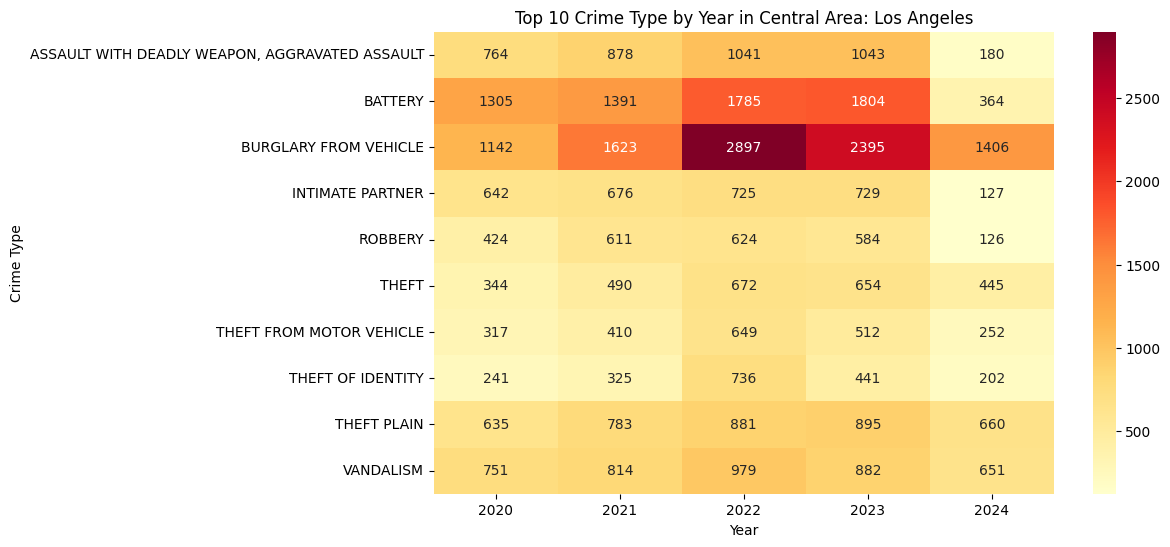

In [ ]:
# Filter Central area
central_data = crime_df[crime_df["AREA NAME"] == "Central"]

# Top crime types
top_crimes = central_data["Crm Cd Desc"].value_counts().nlargest(10).index

# Keep only top crimes
heat_data = central_data[central_data["Crm Cd Desc"].isin(top_crimes)]
crime_df.columns = crime_df.columns.str.strip()
central_data.columns = central_data.columns.str.strip()
# Create pivot table
pivot_table = heat_data.pivot_table(
    index="Crm Cd Desc",
    columns="Year",
    aggfunc="size",
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlOrRd")

plt.title("Top 10 Crime Type by Year in Central Area: Los Angeles")
plt.xlabel("Year")
plt.ylabel("Crime Type")

plt.show()

In [ ]:
crime_df["Year"] = pd.to_datetime(crime_df["DATE OCC"]).dt.year

In [ ]:

crime_df["report_delay_days"] = (crime_df["Date Rptd"] - crime_df["DATE OCC"]).dt.days

crime_df.groupby("type_of_crimes")["report_delay_days"].describe()

,count,mean,std,min,25%,50%,75%,max
type_of_crimes,,,,,,,,
Non Violent,349787.0,20.598719,99.397684,0.0,0.0,0.0,2.0,1862.0
Violent,384099.0,7.906188,46.171160,0.0,0.0,1.0,2.0,1694.0


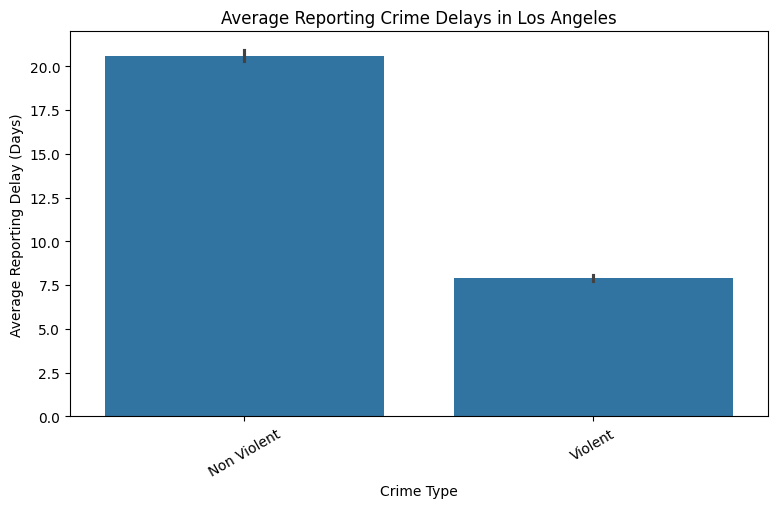

In [ ]:

plt.figure(figsize=(9,5))

sns.barplot(
    data=crime_df,
    x="type_of_crimes",
    y="report_delay_days"
)

plt.title("Average Reporting Crime Delays in Los Angeles")
plt.xlabel("Crime Type")
plt.ylabel("Average Reporting Delay (Days)")

plt.xticks(rotation=30)

plt.show()
  


In [ ]:
yearly_area = crime_df.groupby(["Year", "AREA NAME"]).size().reset_index(name="Crime Count")

C:\Users\That black girl\AppData\Local\Temp\ipykernel_37844\3335516255.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  yearly_area = crime_df.groupby(["Year", "AREA NAME"]).size().reset_index(name="Crime Count")


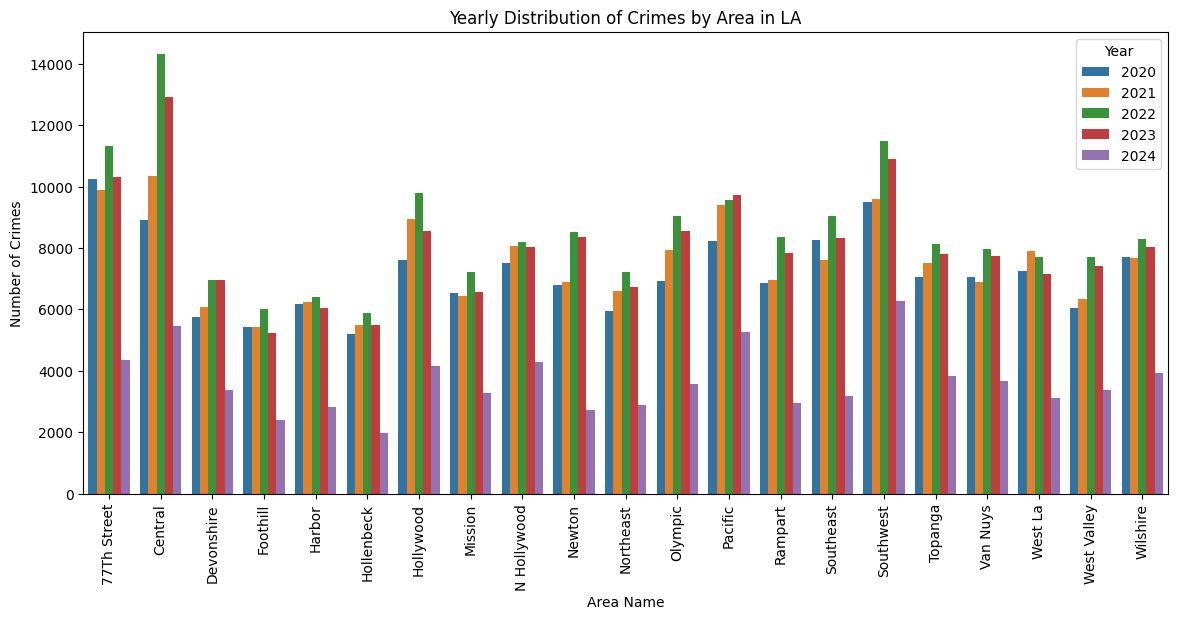

In [ ]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=yearly_area,
    x="AREA NAME",
    y="Crime Count",
    hue="Year",
    palette="tab10",
)

plt.xticks(rotation=90)
plt.title("Yearly Distribution of Crimes by Area in LA")
plt.xlabel("Area Name")
plt.ylabel("Number of Crimes")

plt.show()

In [ ]:
import folium
#from folium.plugins import HeatMap

# Drop missing coordinates
map_data = crime_df.dropna(subset=["LAT", "LON"])

# Create base map centered on Los Angeles
la_map = folium.Map(location=[34.05, -118.25], zoom_start=10)

# Add heatmap
HeatMap(
    data=map_data[["LAT", "LON"]].values.tolist(),
    radius=8,
    blur=6
).add_to(la_map)

la_map

NameError: name 'HeatMap' is not defined

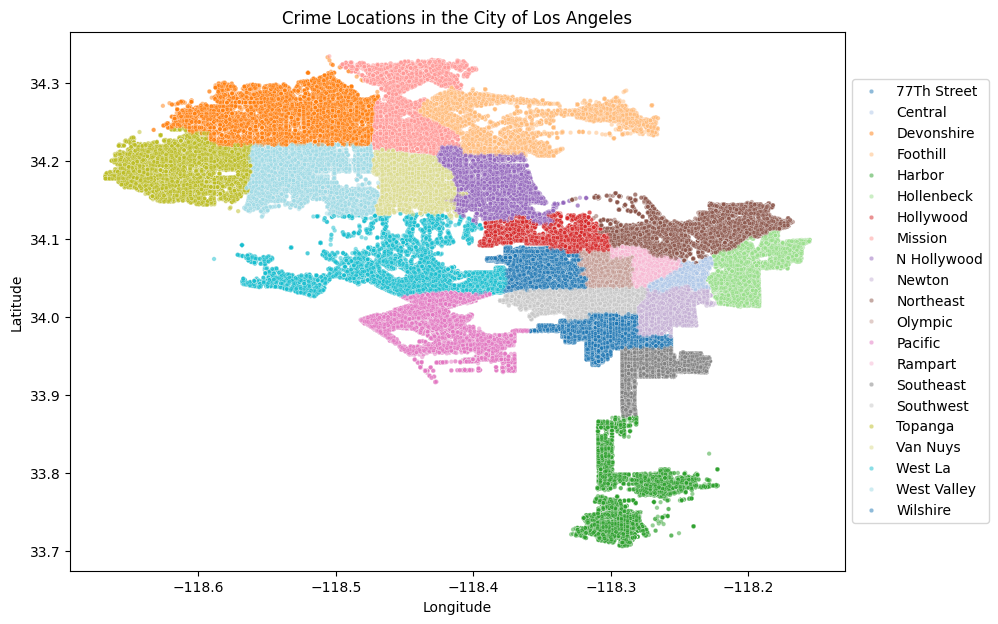

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=crime_df,
    x="LON",
    y="LAT",
    hue="AREA NAME",
    palette="tab20",
    marker="o",
    alpha=0.5,
    s=10
)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Crime Locations in the City of Los Angeles")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

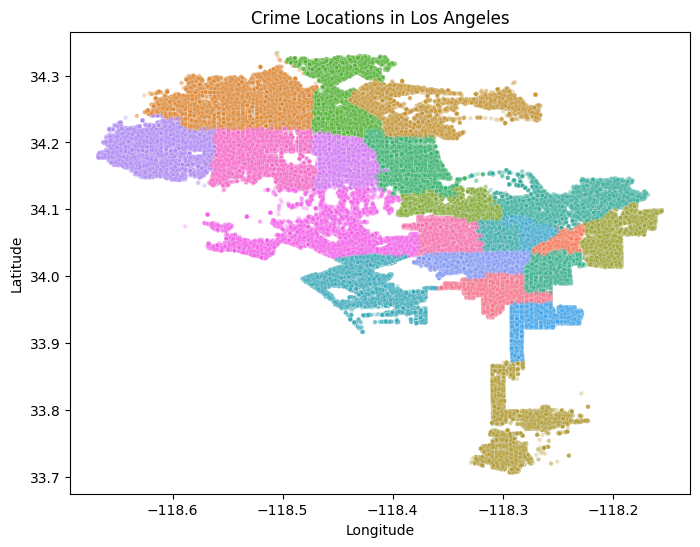

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=crime_df,
    x="LON",
    y="LAT",
    hue="AREA NAME",
    alpha=0.3,
    s=10,
    legend=False
)

plt.title("Crime Locations in Los Angeles")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [ ]:
crime_df = crime_df[crime_df["Vict Sex"] != "-"]

In [ ]:
crime_df = crime_df[crime_df["Vict Sex"] != "-"]

crime_df["Vict Sex"] = crime_df["Vict Sex"].cat.remove_unused_categories()

In [ ]:
crime_df["Monthly"] = crime_df["DATE OCC"].dt.month_name()

In [ ]:
yearly_area = yearly_area.rename(columns={"Crm Cd": "Crime_Code"})

In [ ]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=yearly_area,
    x="Crime_Code",
    y="Crime_Count",
    hue="Year",
    palette="tab10"
)

plt.xticks(rotation=90)
plt.title("Yearly Distribution of Crimes by Crime Code in LA")
plt.xlabel("Crime Code")
plt.ylabel("Number of Crimes")

plt.show()

NameError: name 'plt' is not defined

In [ ]:
crime_df['Crm Cd'].unique()

In [ ]:
vict_count = crime_df.groupby(['age_group', 'Vict Sex'], observed=False).size().unstack()

ax = vict_count.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Set2')

for container in ax.containers:
    labels = [f"{int(v):,}" if v > 5000 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8)

plt.title("Victim Age Groups by Sex")
plt.xlabel("Age Group")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.legend(title="Victim Sex")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,6))

# Scatter plot of crime locations
sns.scatterplot(
    data=crime_df,
    x="LON",
    y="LAT",
    hue="type_of_crime",   # color for crime type
    style="AREA NAME",
    palette="Blues",
    alpha=0.3,
    s=10,
    legend=False
)

# Calculate center of each area
area_centers = crime_df.groupby("AREA NAME")[["LAT","LON"]].mean().reset_index()

# Add labels inside the plot
for _, row in area_centers.iterrows():
    plt.text(
        row["LON"],
        row["LAT"],
        row["AREA NAME"],
        fontsize=8,
        ha="center",
        weight="bold",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

plt.title("Crime Locations in Los Angeles")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get top 20 crime types
top_crimes = crime_df["Crm Cd Desc"].value_counts().head(20)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_crimes.values,
    y=top_crimes.index
)

plt.title("Top 20 Crime Types")
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Type")

plt.show()

KeyError: 'Crm Cd Desc'

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=crime_df,
    y="Vict Descent",
    hue="type_of_crimes",
    palette="viridis"
)

# Add numbers on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.title("Crime Type Distribution by Victim Descent")
plt.xlabel("Number of Crimes")
plt.ylabel("Victim Descent")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=crime_df,
    x="Vict Descent",
    palette="viridis"
)

# Add numbers inside bars
for container in ax.containers:
    ax.bar_label(container, fontsize=8)

plt.xticks(rotation=45)
plt.title("Crime Incidents by Victim Descent")
plt.xlabel("Victim Descent")
plt.ylabel("Number of Crimes")

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
district_crime_counts = crime_df.groupby('AREA NAME').agg(
    latitude=('LAT', 'mean'),
    longitude=('LON', 'mean'),
    counts=('AREA NAME', 'size')
).reset_index()



fig = px.scatter_mapbox(
    district_crime_counts,
    lat="latitude",
    lon="longitude",
    size="counts",
    color="counts",
    hover_name="AREA NAME",
    color_continuous_scale="jet",
    hover_data=["counts"],
    zoom=9,
    height=750,
    width=1200,
    title="Map of Crime Counts by District in Los Angeles"
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

cont_table = pd.crosstab(crime_df['is_night'], crime_df['type_of_crime'])

chi2, p, dof, expected = chi2_contingency(cont_table)

print("Chi-square:", chi2)
print("p-value:", p)

In [ ]:

crime_df["Premis Cd"].value_counts()

In [ ]:
crime_df.shape

In [ ]:
crime_df.drop(columns='type_numeric')

In [ ]:
crime_df.drop(columns='DR_NO')

In [ ]:

crime_df['Year'].value_counts().sort_index()



In [ ]:
crimes_yearly = crimes_yearly[crimes_yearly.index != 2025]

In [ ]:
# Count crimes per year
crimes_yearly = crime_df['Year'].value_counts().sort_index()

plt.figure(figsize=(10,6))
crimes_yearly.plot(kind='line', marker='o')

plt.title('Number of Crime Incidents per Year')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')

plt.xticks(crimes_yearly.index.astype(int))  # remove .0
plt.grid(True)

plt.show()

In [ ]:
print(crimes_yearly)

In [ ]:
crime_df.loc[:, 'MonthName'] = crime_df['DATE OCC'].dt.month_name()

crimes_monthly = crime_df['MonthName'].value_counts().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(10,6))
crimes_monthly.plot(kind='bar')

plt.title('Monthly Crime Trend in Los Angeles From 2020-2024')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Create Year and Month columns
crime_df["Year"] = crime_df["DATE OCC"].dt.year
crime_df["Month"] = crime_df["DATE OCC"].dt.month

# Group data
year_month = crime_df.groupby(["Year","Month"]).size().reset_index(name="Count")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=year_month,
    x="Month",
    y="Count",
    hue="Year",      # each year becomes a different line
    marker="o",
    palette="tab10"
)

plt.title("Crime Trends by Year As of 2020")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")

plt.show()

In [ ]:
crime_df = crime_df[crime_df["Year"] != 2025]

In [ ]:
crime_year_type = crime_df.groupby(["Year","type_of_crimes"]).size().reset_index(name="Count")

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=crime_year_type,
    x="Year",
    y="Count",
    hue="type_of_crimes",
    marker="o"
)

plt.title("Crime Trends by Type Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.xticks(sorted(crime_year_type["Year"].unique()))

plt.show()

In [ ]:
labels = ['Male','Female', 'Unknown']
counts = crime_df['Vict Sex'].value_counts()
counts = counts[counts > 100]

plt.figure(figsize=(12, 6))
plt.title('Crime Victims Based on Gender')
plt.pie(counts, autopct='%1.1f%%', textprops={"fontsize":14})
plt.legend(labels, loc="best")
plt.show()

In [ ]:
for x in crime_df['Crm Cd Desc'].unique():
    print(x)

In [ ]:
crime_df["Year"] = pd.to_datetime(crime_df["DATE OCC"]).dt.year

In [ ]:
crime_df = crime_df[crime_df["Year"] != 2025]

In [ ]:
crime_year_type = crime_df.groupby(["Year", "crime_code_desc"]).size().reset_index(name="Count")

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=crime_year_type,
    x="Year",
    y="Count",
    hue="crime_code_Desc",
    marker="o",
    palette="tab20"
)

plt.title("Crime Trends by Crime Category From 2020–2024")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")



plt.xticks(sorted(crime_year_type["Year"].unique()))

plt.legend(title="Crime Category", bbox_to_anchor=(1.02,1), loc="upper left")

plt.show()

In [ ]:
pivot = crime_df.groupby(["crime_code_Desc","AREA NAME"]).size().unstack(fill_value=0)

plt.figure(figsize=(10,6))

sns.heatmap(pivot, cmap="YlOrRd")

plt.title("Crime Category by LAPD Area from 2020-2025")
plt.xlabel("Area Name")
plt.ylabel("Crime Category")

plt.show()

In [ ]:
crime_df.reset_index(drop=True, inplace=True)

In [ ]:
crime_df.columns

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=crime_year_type,
    x="Year",
    y="Count",
    hue="crime_code_desc",
    marker="o"
)

plt.title("Crime Trends by Category Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric = crime_df.select_dtypes(include=['int64', 'float64'])

sns.pairplot(numeric.sample(1000))
plt.suptitle("Pair Plot Showing all crime features that are numerical")
plt.show()

In [ ]:
print("Original rows:", crime_df.shape[0])
print("Rows after removing missing coordinates:", map_data.shape[0])
print("Rows removed:", crime_df.shape[0] - map_data.shape[0])

In [ ]:
crime_df.head(4)


In [ ]:
crime_df

In [ ]:
crime_df.dtypes

In [ ]:
plt.figure(figsize=(12,8))

cols = ["report_delay_days","hour_occ","Vict Age","Year","LON","LAT","type_of_crime"]
corr = crime_df[cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Crime Features")
plt.show()

In [ ]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=crime_df,
    x="AREA NAME",
    y="Vict Age"
)

plt.xticks(rotation=90)
plt.title("Victim Age Distribution Across Areas")
plt.show()

In [ ]:
crime_df.reset_index()

In [ ]:
crime_df['Premis Cd'].unique()

In [ ]:
crime_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 733886 entries, 0 to 735577
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Date Rptd          733886 non-null  datetime64[ns]
 1   DATE OCC           733886 non-null  datetime64[ns]
 2   AREA NAME          733886 non-null  category      
 3   Crm Cd             733886 non-null  int64         
 4   Crm Cd Desc        733886 non-null  object        
 5   Vict Age           733886 non-null  int64         
 6   Vict Sex           733886 non-null  category      
 7   Vict Descent       733854 non-null  object        
 8   Premis Cd          733885 non-null  float64       
 9   Premis Desc        733657 non-null  category      
 10  Status             733886 non-null  category      
 11  Crm Cd 1           733880 non-null  float64       
 12  LAT                733886 non-null  float64       
 13  LON                733886 non-null  float64      

In [ ]:
crime_df = crime_df.rename(columns={
    "Date Rptd": "Date_Reported",
    "DATE OCC": "Date_Occurred",
    "AREA NAME": "Area_Name",
    "Crm Cd": "Crime_Code",
    "Crm Cd Desc": "Crime_Description",
    "Vict Age": "Victim_Age",
    "Vict Sex": "Victim_Sex",
    "Vict Descent": "Victim_Descent",
    "Premis Cd": "Premise_Code",
    "Premis Desc": "Premise_Description",
    
    "Crm Cd 1": "Serious_Crime_Code",
    "LAT": "Latitude",
    "LON": "Longitude",
    "hour_occ": "Hour_Occurred",
    "age_group": "Victim_Age_Group",
    "Rpt Dist No": "Reported_District_Number"
})

In [ ]:
crime_df = crime_df.drop(columns=["Status"])

In [ ]:
crime_df

,Date_Reported,Date_Occurred,Area_Name,Reported_District_Number,Crime_Code,Crime_Description,Victim_Age,Victim_Sex,Victim_Descent,Premise_Code,Premise_Description,Status,Serious_Crime_Code,Latitude,Longitude,Hour_Occurred,Victim_Age_Group,type_of_crime,is_night,Status_,type_of_crimes,Year,report_delay_days
0,2021-04-11,2020-11-07,N Hollywood,1502,354,THEFT OF IDENTITY,31,Male,Hispanic,501.0,SINGLE FAMILY DWELLING,IC,354.0,34.2124,-118.4092,8,Young_Adult,2,0,Investigation Continued,Non Violent,2020,155
1,2020-10-21,2020-10-18,N Hollywood,1521,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",32,Male,Hispanic,102.0,SIDEWALK,IC,230.0,34.1993,-118.4203,18,Young_Adult,1,1,Investigation Continued,Violent,2020,3
2,2024-12-10,2020-10-30,Van Nuys,933,354,THEFT OF IDENTITY,30,Male,White,501.0,SINGLE FAMILY DWELLING,IC,354.0,34.1847,-118.4509,12,Young_Adult,2,0,Investigation Continued,Non Violent,2020,1502
3,2020-12-24,2020-12-24,Wilshire,782,331,THEFT FROM MOTOR VEHICLE,47,Female,Asian,101.0,STREET,IC,331.0,34.0339,-118.3747,13,Middle_Aged_Adult,1,0,Investigation Continued,Violent,2020,0
4,2020-10-03,2020-09-29,Pacific,1454,420,THEFT FROM MOTOR VEHICLE,63,Male,Hispanic,103.0,ALLEY,IC,420.0,33.9813,-118.4350,18,Older_Adult,1,1,Investigation Continued,Violent,2020,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
735573,2024-10-04,2024-09-27,Central,142,440,THEFT PLAIN,42,Female,Black,122.0,"VEHICLE, PASSENGER/TRUCK",IC,440.0,34.0531,-118.2512,23,Middle_Aged_Adult,1,1,Investigation Continued,Violent,2024,7
735574,2024-08-20,2024-08-17,Olympic,2033,341,THEFT,36,Female,Chinese,207.0,BAR/COCKTAIL/NIGHTCLUB,IC,341.0,34.0617,-118.3066,23,Middle_Aged_Adult,1,1,Investigation Continued,Violent,2024,3
735575,2024-10-16,2024-10-16,Pacific,1489,341,THEFT,46,Male,Hispanic,223.0,VIDEO RENTAL STORE,IC,341.0,33.9469,-118.3703,15,Middle_Aged_Adult,1,0,Investigation Continued,Violent,2024,0
735576,2024-10-14,2024-10-11,Hollenbeck,421,341,THEFT,29,Male,Black,210.0,RESTAURANT/FAST FOOD,IC,341.0,34.0675,-118.2240,23,Young_Adult,1,1,Investigation Continued,Violent,2024,3


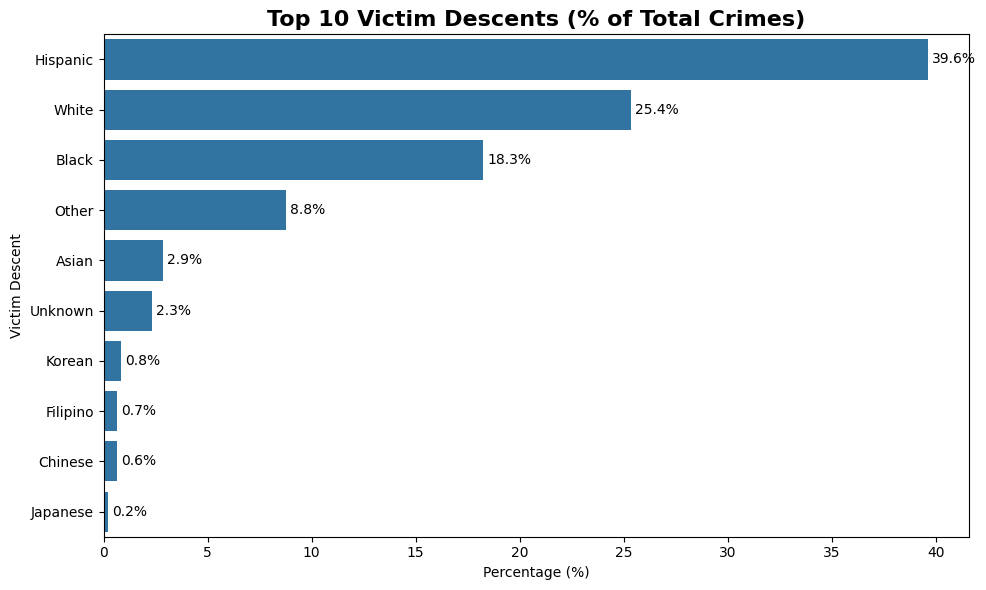

In [28]:
# Top 10 descents
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Get percentage distribution
desc_percent = crime_df['Vict Descent'].value_counts(normalize=True) * 100

# Step 2: Take top 10 (optional but cleaner)
desc_percent = desc_percent.head(10)

# Step 3: Convert to dataframe
desc_df = desc_percent.reset_index()
desc_df.columns = ['Vict Descent', 'Percentage']

# Step 4: Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=desc_df,
    y='Vict Descent',
    x='Percentage'
)

plt.title("Top 10 Victim Descents (% of Total Crimes)", fontsize=16, weight='bold')
plt.xlabel("Percentage (%)")
plt.ylabel("Victim Descent")

# Add labels
for i, v in enumerate(desc_df['Percentage']):
    plt.text(v + 0.2, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.show()

In [ ]:
crime_df.to_parquet("CRIME_DATASET_PROJECT.parquet", index=False)

In [ ]:
crime_df.to_csv("CRIME_DATASET_PROJECT1.csv", index=False)